### Apply on data

In [1]:
import os
import sys

# sys.path.insert(1, os.path.expanduser("~/projects/phase_coupling_analysis/"))

In [2]:
import jax
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import scipy
import xarray as xr
from histogramMI import mutualInformationBin_jax
from hoi.core import get_mi
from mne.filter import filter_data
from mne.time_frequency.tfr import tfr_array_morlet, tfr_array_multitaper
from session import session_info
from tqdm import tqdm

/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 10

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

#### Functions

In [4]:
def trial_to_string(trial_no, n_max):
    trial_no = str(trial_no)
    n = len(trial_no)
    return (n_max - n) * "0" + trial_no

In [5]:
def shuffle_along_axis(a, axis):
    """Shuffle data along specified axis."""
    idx = np.random.rand(*a.shape).argsort(axis=axis)
    return np.take_along_axis(a, idx, axis=axis)


def create_generalized_surrogates(X, n_boot=10000):
    """Create semi-generalized surrogate."""
    T, R, N = X.shape  # Extract dimensions

    # Trials onsets
    t_match_on = (data.attrs["t_match_on"] - data.attrs["t_cue_on"]) / data.fsample
    t_match_on = np.round(t_match_on, 1)

    X = X.values

    # Sample trials
    count = 0
    trials_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(T),
            size=2,
            replace=False,
        )
        trials_surr += [out]
        count = count + 1
    trials_surr = np.stack(trials_surr)

    # Sample channels
    count = 0
    channels_surr = []
    while count < n_boot:
        out = np.random.choice(
            range(R),
            size=2,
            replace=False,
        )
        channels_surr += [out]
        count = count + 1
    channels_surr = np.stack(channels_surr)

    data_surr = []
    for c_i, c_j, trial_i, trial_j in np.concatenate(
        (channels_surr, trials_surr), axis=1
    ):
        x = X[trial_i, c_i]
        y = X[trial_j, c_j]  # [..., ::-1]
        data_surr += [np.stack((x, y))]

    # Get shortest onset time for each pair of sampled trials
    onsets = []
    for t1, t2 in trials_surr:
        onsets += [min(t_match_on[t1], t_match_on[t2])]
    onsets = np.stack(onsets)

    return np.stack(data_surr), onsets

#### Load data

In [7]:
sessions = np.loadtxt("sessions_betty.txt", dtype=str)

print(sys.argv)
if len(sys.argv) > 3:
    index = int(sys.argv[3])
else:
    index = 0

session = sessions[index]

['/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/ipykernel_launcher.py', '-f', '/Users/vinicius/Library/Jupyter/runtime/kernel-2f0b5c25-e29e-4a3b-8329-67040c212a92.json']


In [9]:
root = f"/Users/vinicius/data/GrayLab/betty/{session}/session01/"

save_path = f"figures/data/coherence/{session}"

if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [10]:
trial_info = {}
scipy.io.loadmat(
    os.path.join(root, "trial_info.mat"), simplify_cells=True, mdict=trial_info
)
trial_info = trial_info["trial_info"]

In [11]:
recording_info = {}
scipy.io.loadmat(
    os.path.join(root, "recording_info.mat"), simplify_cells=True, mdict=recording_info
)
recording_info = recording_info["recording_info"]

In [12]:
task_trials = np.where(
    trial_info["behavioral_response"]
    * trial_info["stable_trials"]
    * trial_info["good_trials"]
    * trial_info["rule"]
    == 1
)[0]

In [13]:
time_array = np.arange(-0.4, 1.7, 1 / recording_info["lfp_sampleingrate"])

In [14]:
n_trials, n_channels, n_times = (
    len(task_trials),
    recording_info["channel_count"],
    len(time_array),
)

In [15]:
data = np.empty((n_trials, n_channels, n_times))  # LFP data

# For each selected trial
i = 0
for trial in tqdm(task_trials):

    lfp_data = scipy.io.loadmat(
        os.path.join(root, f"betty{session}01.{trial_to_string(trial + 1, 4)}.mat")
    )["lfp_data"]

    # Beggining and ending time index for this t0
    indb = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.min()
    )
    inde = int(
        trial_info["sample_on"][trial]
        + recording_info["lfp_sampleingrate"] * time_array.max()
    )
    # LFP data, dimension NtrialsxNchannelsxTime
    data[i, ...] = lfp_data[:, indb : inde + 1]

    i = i + 1

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 754/754 [00:01<00:00, 382.56it/s]


#### Convert to xarray

In [16]:
data = xr.DataArray(
    data,
    dims=("trials", "roi", "times"),
    coords=(
        trial_info["match_image"][task_trials],
        recording_info["area"],
        time_array,
    ),
    attrs={
        "t_match_on": trial_info["match_on"],
        "t_cue_on": trial_info["sample_on"],
        "fsample": recording_info["lfp_sampleingrate"],
    },
)

(-0.5, 1.7, -4.561347220428129, 18.97876915494902)

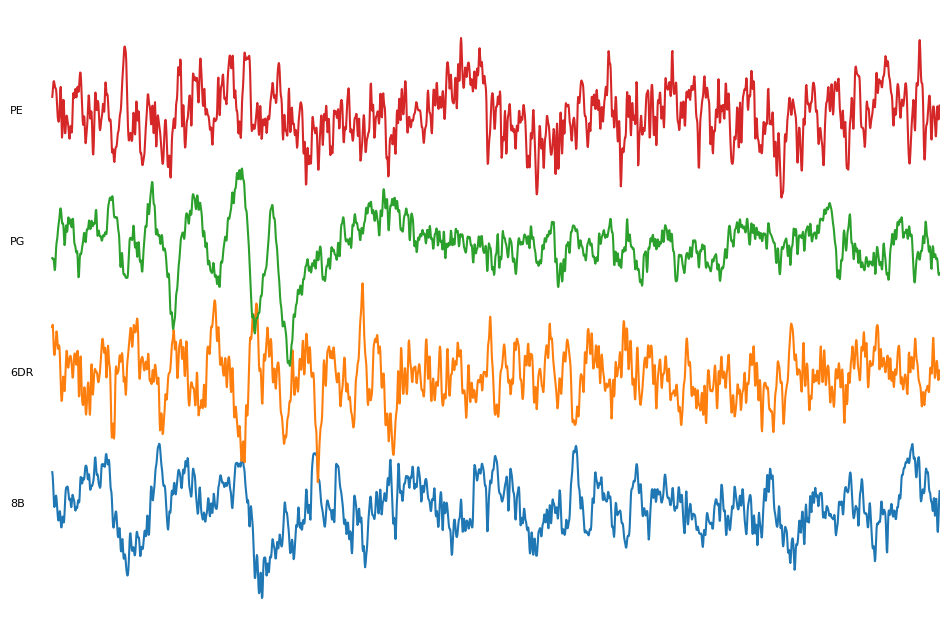

In [17]:
plt.figure(figsize=(12, 8))
zdata = (data - data.mean("times")) / data.std("times")


for i in range(data.sizes["roi"]):

    plt.plot(data.times, zdata[0, i] + (i * 5))
    plt.text(-0.5, (i * 5), zdata.roi.values[i])

plt.xlim(-0.5, 1.7)
plt.axis("off")

#### Surrogate coherence

In [18]:
from frites.utils import parallel_func


def return_coh():

    data_surr, _ = create_generalized_surrogates(data, data.sizes["trials"])

    freqs = np.linspace(0.1, 50, 50)

    W = tfr_array_multitaper(
        data_surr,
        recording_info["lfp_sampleingrate"],
        freqs,
        n_cycles=freqs / 2,
        time_bandwidth=8,
        decim=10,
        output="complex",
        verbose=False,
        n_jobs=1,
    )

    Sxy = (W[:, 0] * np.conj(W[:, 1])).mean(0)
    Sxx = (W[:, 0] * np.conj(W[:, 0])).mean(0)
    Syy = (W[:, 1] * np.conj(W[:, 1])).mean(0)

    return (np.abs(Sxy) ** 2 / (Sxx * Syy)).real


# define the function to compute in parallel
parallel, p_fun = parallel_func(return_coh, n_jobs=10, verbose=False, total=100)
# Compute the single trial coherence
out = parallel(p_fun() for t in range(100))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████|  : 100/100 [02:28<00:00,    1.49s/it]


[0.008532152368325375]


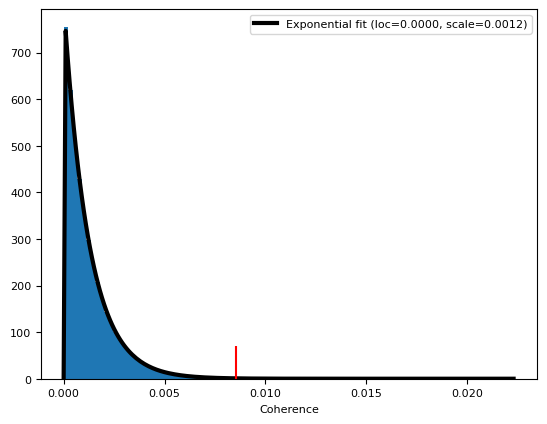

In [21]:
coh_surr_pooled = np.stack(out).flatten()

# Fit the exponential distribution
fit_loc, fit_scale = scipy.stats.expon.fit(coh_surr_pooled)

x = np.arange(0, coh_surr_pooled.max(), 0.0001)

# Calculate the exponential PDF with fit parameters
expon_pdf = scipy.stats.expon.pdf(x, loc=fit_loc, scale=fit_scale)

plt.hist(coh_surr_pooled, 100, density=True)

# Plot the Exponential distribution
plt.plot(
    x,
    expon_pdf,
    label=f"Exponential fit (loc={fit_loc:.4f}, scale={fit_scale:.4f})",
    color="k",
    lw=3,
)

# Calculate thresholds for extreme values
thr_coh = [scipy.stats.expon.ppf(1 - p, loc=fit_loc, scale=fit_scale) for p in [0.001]]

# Plot threshold lines
[plt.vlines(thr_coh[i], 0, 70, color="r") for i in range(len(thr_coh))]
print(thr_coh)
plt.xlabel("Coherence")
plt.legend()
plt.show()

#### Coherence

In [22]:
freqs = np.linspace(0.1, 50, 50)

W = tfr_array_multitaper(
    data,
    recording_info["lfp_sampleingrate"],
    freqs,
    n_cycles=freqs / 2,
    decim=10,
    time_bandwidth=4,
    output="complex",
    verbose=True,
)

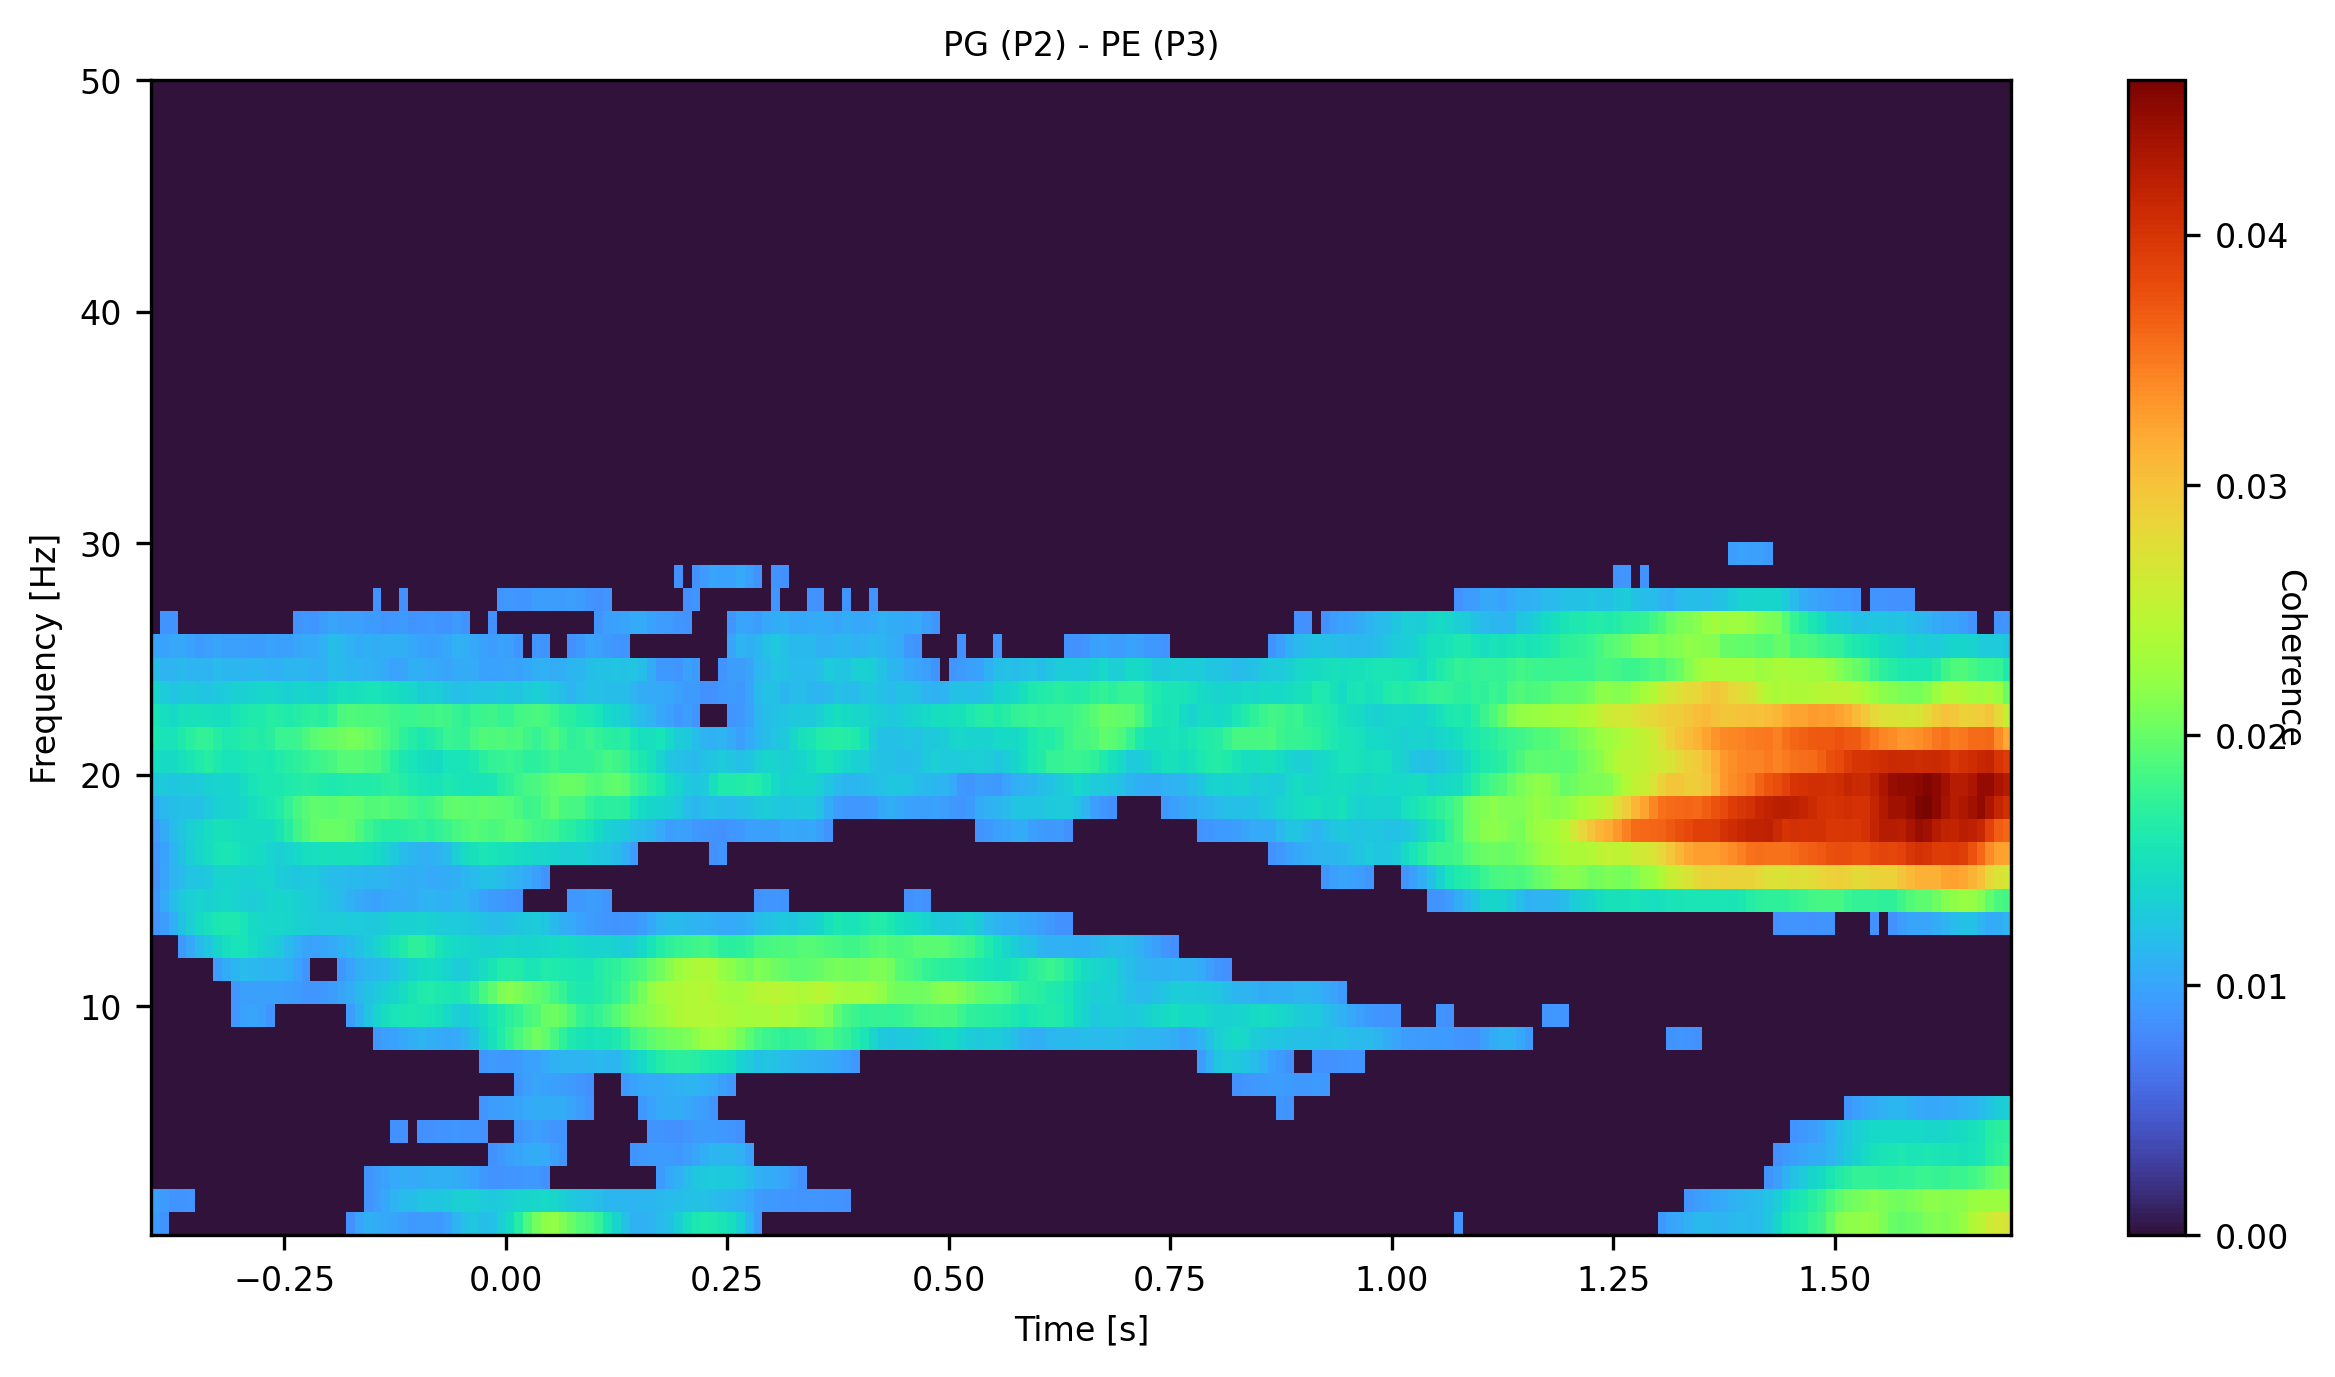

In [24]:
fig = plt.figure(num=1, clear=True, figsize=(10, 5), dpi=300)


for i in range(data.sizes["roi"]):
    for j in range(i + 1, data.sizes["roi"]):

        fig = plt.figure(num=1, clear=True)

        Sxy = (W[:, i] * np.conj(W[:, j])).mean((0, 1))
        Sxx = (W[:, i] * np.conj(W[:, i])).mean((0, 1))
        Syy = (W[:, j] * np.conj(W[:, j])).mean((0, 1))

        coh = np.abs(Sxy) ** 2 / (Sxx * Syy)

        plt.imshow(
            coh.real * (coh.real > thr_coh[0]),
            aspect="auto",
            origin="lower",
            cmap="turbo",
            extent=[time_array.min(), time_array.max(), freqs[0], freqs[-1]],
            vmin=0,
            vmax=coh.real.max(),
        )
        cbar = plt.colorbar()
        a1, a2 = recording_info["cortex"][i], recording_info["cortex"][j]
        cbar.set_label("Coherence", rotation=270)
        plt.xlabel("Time [s]")
        plt.ylabel("Frequency [Hz]")
        plt.title(
            f"{data.roi.values[i]} ({a1}{i}) - {data.roi.values[j]} ({a2}{j})"
        )

        plt.savefig(
            os.path.join(
                save_path,
                f"coherence_spectra_{data.roi.values[i]}_{i} - {data.roi.values[j]}_{j}.pdf",
            )
        )